<a href="https://colab.research.google.com/github/d12eek/ANN-And-DL-Lab-24mcs005/blob/main/GNN_for_Node_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install torch torchvision torchaudio

  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.3.1.170-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nvjitlink_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
Using cached nvidia_cublas_

In [ ]:
pip install numpy matplotlib networkx

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 62.5 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import Planetoid
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [ ]:
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

Processing...
Done!


In [ ]:
print(f"Dataset: {dataset}")
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Number of node features: {data.num_node_features}")
print(f"Number of classes: {dataset.num_classes}")
print(f"Has isolated nodes: {data.has_isolated_nodes()}")
print(f"Has self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")

Dataset: Cora()
Number of nodes: 2708
Number of edges: 10556
Number of node features: 1433
Number of classes: 7
Has isolated nodes: False
Has self-loops: False
Is undirected: True


In [ ]:
# Define the GNN model
class GCN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

In [ ]:
# Initialize the model
model = GCN(num_features=dataset.num_node_features,
            hidden_channels=16,
            num_classes=dataset.num_classes)


In [ ]:
print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.NLLLoss()

In [ ]:
# Training function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

In [ ]:
def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    train_correct = pred[data.train_mask] == data.y[data.train_mask]
    train_acc = int(train_correct.sum()) / int(data.train_mask.sum())

    val_correct = pred[data.val_mask] == data.y[data.val_mask]
    val_acc = int(val_correct.sum()) / int(data.val_mask.sum())

    test_correct = pred[data.test_mask] == data.y[data.test_mask]
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())

    return train_acc, val_acc, test_acc

In [ ]:
train_losses = []
train_accs, val_accs, test_accs = [], [], []

In [ ]:
for epoch in range(1, 201):
    loss = train()
    train_acc, val_acc, test_acc = test()

    train_losses.append(loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    test_accs.append(test_acc)

    if epoch %10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, '
              f'Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, '
              f'Test Acc: {test_acc:.4f}')

Epoch: 010, Loss: 0.0325, Train Acc: 1.0000, Val Acc: 0.7580, Test Acc: 0.7940
Epoch: 020, Loss: 0.0445, Train Acc: 1.0000, Val Acc: 0.7580, Test Acc: 0.7970
Epoch: 030, Loss: 0.0215, Train Acc: 1.0000, Val Acc: 0.7720, Test Acc: 0.7970
Epoch: 040, Loss: 0.0181, Train Acc: 1.0000, Val Acc: 0.7640, Test Acc: 0.7940
Epoch: 050, Loss: 0.0322, Train Acc: 1.0000, Val Acc: 0.7600, Test Acc: 0.7890
Epoch: 060, Loss: 0.0225, Train Acc: 1.0000, Val Acc: 0.7620, Test Acc: 0.7920
Epoch: 070, Loss: 0.0265, Train Acc: 1.0000, Val Acc: 0.7620, Test Acc: 0.8020
Epoch: 080, Loss: 0.0281, Train Acc: 1.0000, Val Acc: 0.7720, Test Acc: 0.7950
Epoch: 090, Loss: 0.0244, Train Acc: 1.0000, Val Acc: 0.7600, Test Acc: 0.7910
Epoch: 100, Loss: 0.0380, Train Acc: 1.0000, Val Acc: 0.7620, Test Acc: 0.8040
Epoch: 110, Loss: 0.0247, Train Acc: 1.0000, Val Acc: 0.7620, Test Acc: 0.7920
Epoch: 120, Loss: 0.0185, Train Acc: 1.0000, Val Acc: 0.7620, Test Acc: 0.7990
Epoch: 130, Loss: 0.0206, Train Acc: 1.0000, Val Acc

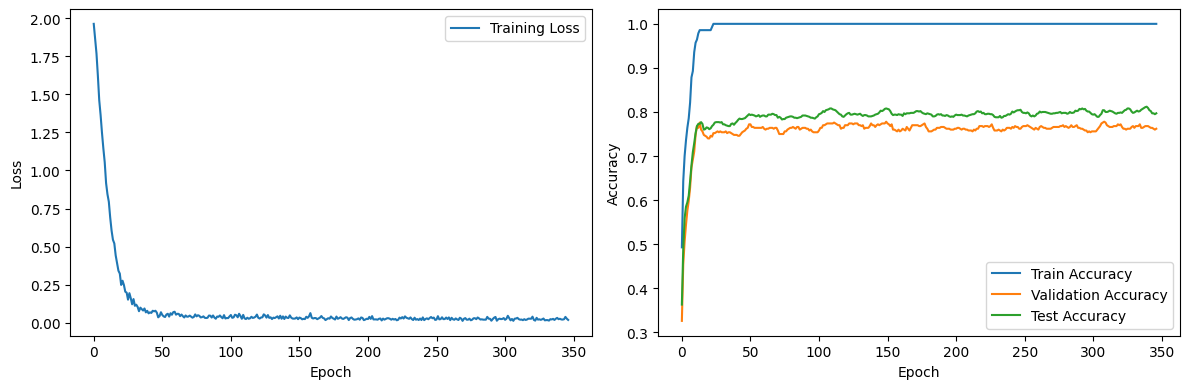

In [ ]:
# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.plot(test_accs, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

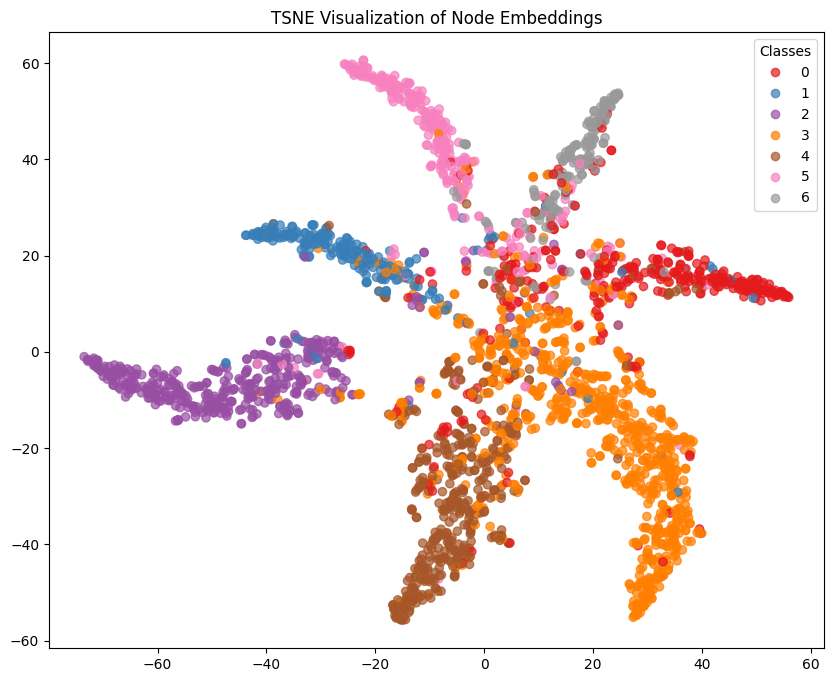

In [ ]:
# Visualize node embeddings
def visualize_embeddings():
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        h = out

    # Use TSNE for dimensionality reduction
    tsne = TSNE(n_components=2, random_state=42)
    h_2d = tsne.fit_transform(h.cpu().numpy())


    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(h_2d[:, 0], h_2d[:, 1], c=data.y.cpu().numpy(),
                         cmap='Set1', alpha=0.7)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.title('TSNE Visualization of Node Embeddings')
    plt.show()

visualize_embeddings()